## **0. Settings**

In [3]:
import os, sys
sys.path.append(os.path.abspath('..'))

## **1. Import Libraries**

In [4]:
import torch
from transformers import AutoTokenizer
from src.training import model 
from src.evaluation import inference
from src.explainability import attribution, visualizer

## **2. Load Model & Tokenizer**

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = AutoTokenizer.from_pretrained('Qualcomm-AI-Research/BamiBERT')
model = model.AIContentModel(model_name='Qualcomm-AI-Research/BamiBERT', num_classes=2)
checkpoint = torch.load('../models/best_model.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

e:\Projects\AI Content Detection\venv\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
Some weights of RobertaModel were not initialized from the model checkpoint at Qualcomm-AI-Research/BamiBERT and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


AIContentModel(
  (bert): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(20481, 768, padding_idx=1)
      (position_embeddings): Embedding(2050, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerN

## **3. Input Real Article for Testing**

In [6]:
article_text = """
Meta, TikTok đề xuất không cấm trẻ tương tác trên mạng xã hội
Đại diện Meta và TikTok tại Việt Nam đề nghị cân nhắc nới lỏng quy định cấm người dùng dưới 16 tuổi đăng bài, bình luận và chia sẻ trên mạng xã hội.

Bộ Văn hóa, Thể thao và Du lịch đang lấy ý kiến dự thảo sửa đổi Nghị định 147 về quản lý việc cung cấp, sử dụng Internet và thông tin trên mạng. Trong đó, dự thảo đề xuất không cho người dưới 16 tuổi đăng bài, bình luận, chia sẻ hoặc bày tỏ cảm xúc trên mạng xã hội.

Ông Nguyễn Lâm Thanh, Giám đốc TikTok Việt Nam, đánh giá việc tăng cường bảo vệ trẻ em rất cần thiết, nhưng quy định cấm hoàn toàn tương tác nên được cân nhắc.

Theo ông, hầu hết ứng dụng trên mạng hiện nay thực tế đều có tính năng như của mạng xã hội. Nếu trẻ dưới 16 tuổi không thể đăng bài, bình luận, chia sẻ, "gần như chúng ta sẽ cấm hẳn người dùng U16 hoạt động trên không gian mạng", ông nói, thêm rằng quy định mới có thể mâu thuẫn với Chương trình bảo vệ và hỗ trợ trẻ em tương tác lành mạnh, sáng tạo trên môi trường mạng của Chính phủ.

Ông cho rằng các nền tảng đều có chế độ tài khoản dành cho trẻ em với sự giám sát của cha mẹ hoặc người giám hộ. Thay vì cấm, cơ quan quản lý có thể tăng trách nhiệm của người giám hộ bằng giải pháp kỹ thuật.
Bà Nguyễn Thu Thảo, Giám đốc Chính sách công phụ trách thị trường Việt Nam của Meta, đưa ra quan điểm tương tự. Theo bà, các nền tảng đang xác định tài khoản có khả năng là trẻ em dựa trên một số đặc điểm hành vi và hoạt động, kết hợp sử dụng AI để ước tính độ tuổi.

"Nếu trẻ chỉ dùng mạng xã hội một cách thụ động, các nền tảng sẽ không còn tín hiệu hành vi cần thiết để nhận diện người dùng là trẻ em, có thể làm giảm hiệu quả của biện pháp phát hiện và bảo vệ trẻ", đại diện Meta nói. Bà lấy dẫn chứng nhiều quốc gia ưu tiên biện pháp bảo vệ theo mức độ hoặc phù hợp từng nhóm tuổi chưa không cấm trẻ tương tác.

Lập luận của TikTok và Meta tại Việt Nam cũng giống với quan điểm của bà Bùi Thị Việt Lâm, đại diện Hội đồng kinh doanh Hoa Kỳ - ASEAN (USABC) tại Việt Nam. Theo bà, USABC và các doanh nghiệp thành viên đồng tình với việc tăng cường bảo vệ trẻ trên môi trường mạng, nhưng cấm hoàn toàn tương tác có thể khiến họ khó phát hiện tài khoản của trẻ hơn.

Bà phân tích, người dùng khai báo ngày tháng năm sinh khi tạo tài khoản chỉ là lớp bảo vệ ban đầu và tương đối yếu. Trẻ có thể khai tăng tuổi để sử dụng đầy đủ tính năng của nền tảng, còn các nền tảng đều có công cụ phân tích tín hiệu hành vi để dự đoán độ tuổi.

Chẳng hạn, khi một tài khoản thường xuyên tương tác với nội dung cho lứa tuổi thiếu niên hoặc dành cho người trưởng thành, hệ thống sẽ nhận diện và đưa ra đánh giá phù hợp. Quy định cấm vô hình trung khiến việc phát hiện và áp dụng biện pháp bảo vệ trẻ em trở nên khó khăn hơn. Chưa kể, một lệnh cấm toàn diện có thể dẫn đến tình trạng khai báo tăng độ tuổi, lúc này trẻ không còn được bảo vệ bởi cơ chế dành riêng nữa.

"Chúng ta đang nhìn mạng xã hội dưới góc độ hoàn toàn tiêu cực. Còn những tác động tích cực thì sao, như giúp trẻ tăng tương tác xã hội, phục vụ học tập", bà Lâm đặt vấn đề.

Do đó, đại diện USABC kiến nghị điều chỉnh quy định theo hướng kiểm soát nội dung, bảo vệ quyền riêng tư, hạn chế liên hệ từ người lạ, quản lý thời gian sử dụng và trao cho cha mẹ công cụ giám sát phù hợp. "Đây là cách tiếp cận dựa trên độ tuổi và mức độ rủi ro, đã được chứng minh hiệu quả tại nhiều quốc gia", bà nói.
Giải thích về đề xuất, ông Lê Quang Tự Do, Cục trưởng Phát thanh, truyền hình và thông tin điện tử, cho biết ban soạn thảo nhận thấy việc để trẻ em bình luận và tương tác trên mạng xã hội có thể dẫn đến hai tình huống. Một là các bình luận mang tính xúc phạm, tiêu cực gây tác hại xấu đến nhận thức, cảm xúc của trẻ. Hai là nguy cơ về lừa đảo qua mạng.

"Đó là những lý do ban soạn thảo đề xuất quy định này", ông nói.

Ban soạn thảo cho biết sẽ cân nhắc các góp ý, đồng thời nghiên cứu phương án bổ sung trường thông tin để nền tảng nhận diện tài khoản trẻ em ngay từ khi phụ huynh đăng ký, qua đó áp dụng cơ chế phân phối nội dung và bảo vệ phù hợp.

Nghị định sửa đổi, bổ sung Nghị định 147/2024 nhằm cập nhật các quy định về phân cấp, phân quyền, cắt giảm thủ tục hành chính và thể chế hóa các chủ trương theo Chỉ thị 05 về tăng cường quản lý thông tin trên môi trường mạng, bảo vệ trẻ em và nâng cao hiệu lực quản lý nhà nước trong bối cảnh chuyển đổi số. Trong đó, dự thảo cũng quy định trẻ dưới 16 tuổi chỉ được chơi game 60 phút mỗi ngày, thay vì 180 phút như văn bản hiện hành.
"""

In [7]:
result = inference.predict_single_text(
    model, tokenizer, article_text, device, max_length=1024
)

print(f"Predict: {result['predicted_class']}")
print(f"Human Probability: {result['prob_human']:.3f}")
print(f"AI Probability:    {result['prob_ai']:.3f}")
print()
print('Text after cleaning:')
print(result['cleaned_text'][:300], '...')

Predict: Human
Human Probability: 0.996
AI Probability:    0.004

Text after cleaning:
Meta, TikTok đề xuất không cấm trẻ tương tác trên mạng xã hội Đại diện Meta và TikTok tại Việt Nam đề nghị cân nhắc nới lỏng quy định cấm người dùng dưới 16 tuổi đăng bài, bình luận và chia sẻ trên mạng xã hội. Bộ Văn hóa, Thể thao và Du lịch đang lấy ý kiến dự thảo sửa đổi Nghị định 147 về quản lý  ...


## **4. Explain Prediction**

In [8]:
explainer = attribution.AttributionExplainer(model, tokenizer, device, max_length=512)

target = result['predicted_label']  
explain_result = explainer.explain(result['cleaned_text'], target_label=target, n_steps=5)

In [9]:
visualizer.highlight_text(
    explain_result['tokens'],
    explain_result['scores'],
    title='Attribution - Bài báo test',
    pred_label=result['predicted_class'],
    pred_prob=explain_result['pred_prob']
)

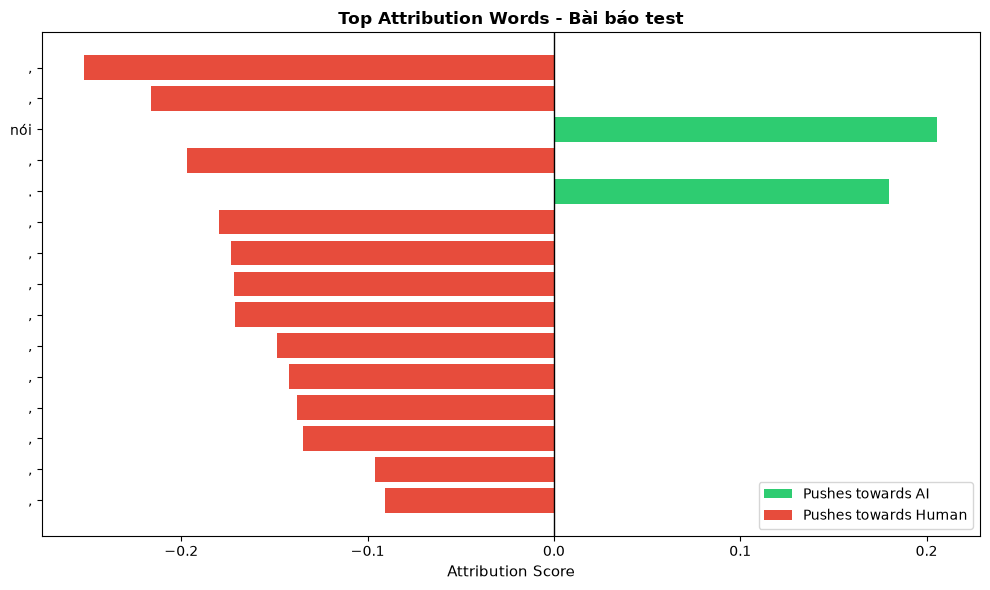

In [10]:
visualizer.plot_token_attribution(
    explain_result['tokens'],
    explain_result['scores'],
    title='Top Attribution Words - Bài báo test',
    top_k=15
)